# Baseline Models - ResNet-18 Comparison

**Research Question:** How do different pretraining sources and training strategies affect CNN performance?

## 2x2 Experimental Design:

|  | Linear Probing | Fine-Tuning |
|---|---|---|
| **ImageNet** | Model A | Model B |
| **Flowers-102** | Model C | Model D |

---

## How to Use This Notebook:

1. **Restart Kernel** (if needed)
2. **Run All "RUN EVERY TIME" cells** (Blocks 0-7)
3. **Run Training** (Block 8/9) - only once, takes ~30-60 min
4. **Run Evaluation** (Block 10) - after training completes

See the **Quick Reference** table at the bottom for details.

In [1]:
# Device Initialization (GPU/CPU) and Test Loader Setup
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import os
from pathlib import Path

# Set device
if 'device' not in dir():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device set: {device}")
else:
    print(f"Device already set: {device}")

# Check and initialize Test Loader
possible_test_paths = [
    Path(r"C:/Users/Elahe/Desktop/Repo-xAI-Proj-B/block-4-5-model-ab-fatemeh/notebooks/data/xAI_ImageNet1k_OwnTestSet/xai-imagenet10-hard-test"),
    Path("./data/xAI_ImageNet1k_OwnTestSet/xai-imagenet10-hard-test"),
    Path("../notebooks/data/xAI_ImageNet1k_OwnTestSet/xai-imagenet10-hard-test"),
]

test_dir = None
for p in possible_test_paths:
    if p.exists() and p.is_dir():
        subdirs = [d for d in p.iterdir() if d.is_dir()]
        if len(subdirs) > 0:
            test_dir = p
            print(f"Found test directory: {p}")
            break

if test_dir is not None:
    test_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    test_dataset_block9 = datasets.ImageFolder(str(test_dir), test_transform)
    test_loader = DataLoader(test_dataset_block9, batch_size=32, shuffle=False, num_workers=0)
    print(f"Test Loader initialized: {len(test_dataset_block9)} images")
else:
    print("Test dataset not found. Test Loader not available.")
    print("Expected: notebooks/data/xAI_ImageNet1k_OwnTestSet/xai-imagenet10-hard-test")


Device set: cuda
Found test directory: C:\Users\Elahe\Desktop\Repo-xAI-Proj-B\block-4-5-model-ab-fatemeh\notebooks\data\xAI_ImageNet1k_OwnTestSet\xai-imagenet10-hard-test
Test Loader initialized: 4409 images


## Block 0 - Imports & Setup

**RUN EVERY TIME** (Run after every kernel restart)

This block loads all required libraries and configures GPU/CPU.

In [2]:
# Block 0 - Imports & Setup
# ═══════════════════════════════════════════════════════════════════════════════
#
# What this block does:
# 1. Imports required libraries (PyTorch, torchvision, numpy, ...)
# 2. Sets up GPU or CPU for computation
# 3. Defines utility functions for visualization
#
# Run this block FIRST before running any other block.

import os                                    # For file and folder operations
import warnings                              # For managing warning messages
from torchvision import datasets, transforms, models  
# datasets: For loading datasets (ImageFolder, CIFAR10, ...)
# transforms: For image preprocessing (Resize, Normalize, ...)
# models: For pretrained models (ResNet, VGG, ...)

from torch.utils.data import DataLoader      # For loading data in batches
import torch                                 # Main PyTorch library
import torch.nn as nn                        # Neural network layers (Linear, Conv2d, ...)
import torch.optim as optim                  # Optimizers (SGD, Adam, ...)
import copy                                  # For deep copy of model (save best weights)
from pathlib import Path                     # For cross-platform path management
import random                                # Python random number generation
import numpy as np                           # Numerical computations (arrays, matrices)

# ============ CHECKPOINT PATH (with fallback detection) ============
# This file contains ResNet-18 weights trained on Flowers-102 dataset
# Used for Model C and Model D
possible_flower_paths = [
    Path(r"C:/Users/Elahe/Desktop/Repo-xAI-Proj-B/block-4-5-model-ab-fatemeh/notebooks/models/flower_resnet18_state.pth"),
    Path("./models/flower_resnet18_state.pth"),
    Path("../notebooks/models/flower_resnet18_state.pth"),
    Path("notebooks/models/flower_resnet18_state.pth"),
]

FLOWER_CKPT = None
for p in possible_flower_paths:
    if p.exists():
        FLOWER_CKPT = str(p.resolve())
        break

if FLOWER_CKPT is None:
    FLOWER_CKPT = "./models/flower_resnet18_state.pth"  # Default fallback

# ============ REPRODUCIBILITY ============
# By setting seed, results will be the same each time the code runs
# This is very important for scientific research
torch.manual_seed(42)                        # Seed for PyTorch
np.random.seed(42)                           # Seed for NumPy
random.seed(42)                              # Seed for Python

# ============ cuDNN SETTINGS ============
# cuDNN is NVIDIA's library for neural networks
torch.backends.cudnn.deterministic = True    # Deterministic results (always the same)
torch.backends.cudnn.benchmark = False       # Disable auto-tuning (slower but reproducible)

# ============ DEVICE SELECTION ============
# PyTorch can run on GPU (faster) or CPU (always available)
if torch.cuda.is_available():                # Is NVIDIA GPU available?
    device = torch.device('cuda')            # Use GPU
    print("✅ CUDA GPU is available! Training on CUDA...")
else:
    device = torch.device('cpu')             # Use CPU
    print("⚠️ No GPU found. Training on CPU...")

print("Using device:", device)

# ============ SUPPRESS WARNINGS ============
warnings.filterwarnings("ignore", message=".*cuDNN.*")
warnings.filterwarnings("ignore", category=UserWarning, module="torch.backends.cudnn")

# ============ VERIFY CHECKPOINT ============
flower_path = Path(FLOWER_CKPT)
if flower_path.exists():
    print(f"✅ Flower checkpoint found: {flower_path.resolve()}")
else:
    print(f"⚠️ Flower checkpoint NOT found at: {flower_path.resolve()}")
    print("   To create it, run: python scripts/train_flower_pretrain.py")
    print("   Models C and D will be skipped during training.")


✅ CUDA GPU is available! Training on CUDA...
Using device: cuda
✅ Flower checkpoint found: C:\Users\Elahe\Desktop\Repo-xAI-Proj-B\block-4-5-model-ab-fatemeh\notebooks\models\flower_resnet18_state.pth


## Block 1 - Dataset & DataLoader Setup

**RUN EVERY TIME** (Run after every kernel restart)

This block loads the datasets (Train/Val/Test).

In [3]:
# ╔═══════════════════════════════════════════════════════════════════════════════╗
# ║  BLOCK 1 - DATASET & DATALOADER SETUP                                          ║
# ╚═══════════════════════════════════════════════════════════════════════════════╝
#
# What this block does:
# ─────────────────────
# 1. Defines paths for train, val, test folders
# 2. Defines image transforms (Resize, Normalize, Augmentation)
# 3. Creates DataLoaders for batch processing
#
# Dataset structure:
# - Training set: Used for model training
# - Validation set: Used for hyperparameter tuning and early stopping
# - Test set: Used for final evaluation (only run once at the end)
from pathlib import Path
from torchvision import transforms
from torchvision import datasets
from torch.utils.data import DataLoader

# ============ DEFINE PATHS ============
data_root = Path("./data")                    # Main data folder
imagenet_root = data_root / "ImageNetSubset"  # ImageNet subfolder
train_dir = imagenet_root / "train"           # Training images folder (13,000 images)
val_dir = imagenet_root / "val"               # Validation images folder (500 images)
test_dir = data_root / "xAI_ImageNet1k_OwnTestSet" / "xai-imagenet10-hard-test"  # Test folder (4,409 images)

print("train_dir:", train_dir.resolve(), "exists?", train_dir.exists())
print("val_dir  :", val_dir.resolve(),   "exists?", val_dir.exists())
print("test_dir :", test_dir.resolve(),  "exists?", test_dir.exists())

# ============ IMAGE SIZE ============
input_size = 224  # ResNet-18 is designed for 224x224 images

# ============ DATA TRANSFORMS ============
data_transforms = {
    # TRAIN TRANSFORMS (with Augmentation for more variety)
    "train": transforms.Compose([
        transforms.Resize((input_size, input_size)),  # Resize to 224x224
        transforms.RandomHorizontalFlip(),             # Random horizontal flip (50%)
        transforms.RandomRotation(15),                 # Random rotation ±15 degrees
        transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),   # Random color jitter
        transforms.ToTensor(),                         # Convert to Tensor [0-1]
        transforms.Normalize([0.485, 0.456, 0.406],   # Normalize with ImageNet mean
                             [0.229, 0.224, 0.225]),
    ]),
    # VAL/TEST TRANSFORMS (without Augmentation)
    "val": transforms.Compose([
        transforms.Resize((input_size, input_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]),
}

# ============ HELPER FUNCTION ============
def has_images(directory: Path):
    """Check if images exist in folder"""
    if not directory.exists():
        return False
    valid_extensions = {".jpg", ".jpeg", ".JPG", ".JPEG", ".png", ".PNG"}
    for f in directory.rglob("*"):
        if f.suffix in valid_extensions:
            return True
    return False

# ============ LOAD DATASETS ============
if has_images(train_dir) and has_images(val_dir):
    print("Using real ImageNetSubset dataset (ImageFolder)")
    image_datasets = {
        "train": datasets.ImageFolder(train_dir, data_transforms["train"]),
        "val": datasets.ImageFolder(val_dir, data_transforms["val"]),
    }
    num_classes = len(image_datasets["train"].classes)
    class_names = image_datasets["train"].classes

    if has_images(test_dir):
        image_datasets["test"] = datasets.ImageFolder(test_dir, data_transforms["val"])
        print("Test set loaded from xAI_ImageNet1k_OwnTestSet")
    else:
        print("WARNING: Test set not found at", test_dir.resolve())
else:
    print("WARNING: No real dataset found. Using FakeData.")
    num_classes = 10
    class_names = [f"class_{i}" for i in range(num_classes)]
    image_datasets = {
        "train": datasets.FakeData(size=64, image_size=(3, input_size, input_size),
                                   num_classes=num_classes, transform=data_transforms["train"]),
        "val": datasets.FakeData(size=32, image_size=(3, input_size, input_size),
                                 num_classes=num_classes, transform=data_transforms["val"]),
    }

# ============ CREATE DATALOADERS ============
batch_size = 32   # Number of images per batch
num_workers = 0   # Number of parallel workers (0 for Windows/Jupyter)

dataloader = {
    "train": DataLoader(image_datasets["train"], batch_size=batch_size, shuffle=True, num_workers=num_workers),
    "val": DataLoader(image_datasets["val"], batch_size=batch_size, shuffle=False, num_workers=num_workers),
}

if "test" in image_datasets:
    dataloader["test"] = DataLoader(image_datasets["test"], batch_size=batch_size, shuffle=False, num_workers=num_workers)

# ============ PRINT SUMMARY ============
print("\n" + "="*50)
print("DATASET SUMMARY")
print("="*50)
print(f"Train samples:      {len(image_datasets['train']):,}")
print(f"Validation samples: {len(image_datasets['val']):,}")
if "test" in image_datasets:
    print(f"Test samples:       {len(image_datasets['test']):,}")
print(f"Num classes:        {num_classes}")
print(f"Classes:            {class_names}")
print("="*50)

train_dir: C:\Users\Elahe\Desktop\Repo-xAI-Proj-B\block-4-5-model-ab-fatemeh\notebooks\data\ImageNetSubset\train exists? True
val_dir  : C:\Users\Elahe\Desktop\Repo-xAI-Proj-B\block-4-5-model-ab-fatemeh\notebooks\data\ImageNetSubset\val exists? True
test_dir : C:\Users\Elahe\Desktop\Repo-xAI-Proj-B\block-4-5-model-ab-fatemeh\notebooks\data\xAI_ImageNet1k_OwnTestSet\xai-imagenet10-hard-test exists? True
Using real ImageNetSubset dataset (ImageFolder)
Test set loaded from xAI_ImageNet1k_OwnTestSet

DATASET SUMMARY
Train samples:      13,000
Validation samples: 500
Test samples:       4,409
Num classes:        10
Classes:            ['binder', 'coffee_mug', 'computer_keyboard', 'mouse', 'notebook', 'remote_control', 'soup_bowl', 'teapot', 'toilet_tissue', 'wooden_spoon']


## Block 2 - Training Function

**RUN EVERY TIME** (Run after every kernel restart)

Defines the `train_model()` function for training models.

In [4]:
# ╔═══════════════════════════════════════════════════════════════════════════════╗
# ║  BLOCK 2 - TRAINING FUNCTION                                                    ║
# ╚═══════════════════════════════════════════════════════════════════════════════╝
#
# What this block does:
# ─────────────────────
# Defines the train_model() function which:
# 1. Trains the model for multiple epochs
# 2. After each epoch, evaluates on validation set
# 3. Saves the best model weights (based on validation accuracy)
# 4. Returns training history for plotting
import torch
import torch.nn as nn
import torch.optim as optim
import copy

def train_model(
    model,                                   # Neural network model
    train_loader,                            # Training DataLoader
    val_loader,                              # Validation DataLoader
    device,                                  # 'cuda' or 'cpu'
    num_epochs,                              # Number of epochs
    lr=1e-4,                                 # Learning rate
    save_path="./models/best_model.pth",     # Path to save best model
):
    """
    Classification model training function

    Args:
        model: PyTorch model
        train_loader: DataLoader for training data
        val_loader: DataLoader for validation data
        device: Computation device (cuda/cpu)
        num_epochs: Number of training epochs
        lr: Learning rate
        save_path: Model save path

    Returns:
        model: Trained model with best weights
        best_acc: Best validation accuracy
        history: History of loss and accuracy
    """

    # ============ SETUP ============
    model = model.to(device)                 # Move model to GPU/CPU

    # ═══════════════════════════════════════════════════════════════════
    # LOSS FUNCTION
    # ═══════════════════════════════════════════════════════════════════
    # CrossEntropyLoss is used for multi-class classification
    # This function computes the difference between model prediction and actual label
    criterion = nn.CrossEntropyLoss()

    # ═══════════════════════════════════════════════════════════════════
    # OPTIMIZER
    # ═══════════════════════════════════════════════════════════════════
    # SGD with momentum: one of the most popular optimizers
    # Only updates trainable parameters (requires_grad=True)
    optimizer = optim.SGD(
        filter(lambda p: p.requires_grad, model.parameters()),  # Only trainable parameters
        lr=lr,                               # Learning rate
        momentum=0.9,                        # Momentum for faster convergence
    )

    dataset_sizes = {
        "train": len(train_loader.dataset),
        "val": len(val_loader.dataset),
    }

    best_acc = 0.0                           # Best validation accuracy
    best_state = copy.deepcopy(model.state_dict())  # Copy of initial weights

    # History for plotting
    history = {
        "train_loss": [],    # Training loss per epoch
        "val_loss": [],      # Validation loss per epoch
        "train_acc": [],     # Training accuracy per epoch
        "val_acc": [],       # Validation accuracy per epoch
    }

    # ═══════════════════════════════════════════════════════════════════
    # TRAINING LOOP
    # ═══════════════════════════════════════════════════════════════════
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        # ════════════════════════════════════════════════════════════════
        # TRAIN PHASE
        # ════════════════════════════════════════════════════════════════
        model.train()                        # Enable training mode (Dropout and BatchNorm active)
        running_loss = 0.0                   # Sum of losses
        running_corrects = 0                 # Number of correct predictions

        for inputs, labels in train_loader:  # Iterate over batches
            inputs = inputs.to(device)       # Move images to GPU/CPU
            labels = labels.to(device)       # Move labels

            # 1. Zero previous gradients
            optimizer.zero_grad(set_to_none=True)

            # 2. Forward Pass: compute model output
            outputs = model(inputs)          # outputs shape: [batch_size, num_classes]

            # 3. Compute Loss
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)  # Prediction = class with highest score

            # 4. Backward Pass: compute gradients
            loss.backward()                  # Backpropagation

            # 5. Update weights
            optimizer.step()                 # Weights are updated

            running_loss += loss.item() * inputs.size(0)
            running_corrects += (preds == labels).sum().item()

        # Compute averages for this epoch
        train_epoch_loss = running_loss / dataset_sizes["train"]
        train_epoch_acc = running_corrects / dataset_sizes["train"]
        history["train_loss"].append(train_epoch_loss)
        history["train_acc"].append(train_epoch_acc)

        print(f"train  Loss: {train_epoch_loss:.4f}  Acc: {train_epoch_acc:.4f}")

        # ════════════════════════════════════════════════════════════════
        # VALIDATION PHASE
        # ════════════════════════════════════════════════════════════════
        model.eval()                         # Disable Dropout and BatchNorm
        running_loss = 0.0
        running_corrects = 0

        with torch.no_grad():                # Disable gradient computation (faster)
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)      # Only Forward Pass
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)

                running_loss += loss.item() * inputs.size(0)
                running_corrects += (preds == labels).sum().item()

        val_epoch_loss = running_loss / dataset_sizes["val"]
        val_epoch_acc = running_corrects / dataset_sizes["val"]
        history["val_loss"].append(val_epoch_loss)
        history["val_acc"].append(val_epoch_acc)

        print(f"val    Loss: {val_epoch_loss:.4f}  Acc: {val_epoch_acc:.4f}")

        # ════════════════════════════════════════════════════════════════
        # SAVE BEST MODEL
        # ════════════════════════════════════════════════════════════════
        if val_epoch_acc > best_acc:         # If this epoch was best
            best_acc = val_epoch_acc         # Update best accuracy
            best_state = copy.deepcopy(model.state_dict())  # Copy weights
            torch.save(best_state, save_path)  # Save to disk
            print(f"  ↳ New best! Saved to {save_path}")

    # ============ FINISH ============
    print(f"\nBest val Acc: {best_acc:.4f}")
    model.load_state_dict(best_state)        # Load best weights

    return model, best_acc, history

print("✅ train_model() function defined successfully.")

✅ train_model() function defined successfully.


## Block 2.5 - Test Evaluation Function

**RUN EVERY TIME** (Run after every kernel restart)

Defines `evaluate_on_test()` and `print_test_results()` functions for Test Set evaluation.

In [5]:
# Test GPU is being used

print(f"Device: {device}")
print(f"CUDA available: {torch.cuda.is_available()}")

if device.type == 'cuda':
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
    
    # Test tensor on GPU
    test = torch.tensor([1.0, 2.0], device=device)
    print(f"Test tensor on: {test.device}")
    print("✅ GPU is working!")
else:
    print("❌ Using CPU, not GPU")

Device: cuda
CUDA available: True
GPU name: NVIDIA GeForce RTX 5060 Ti
GPU memory: 15.9 GB
Test tensor on: cuda:0
✅ GPU is working!


In [6]:
# ╔═══════════════════════════════════════════════════════════════════════════════╗
# ║  BLOCK 2.5 - TEST EVALUATION FUNCTION                                          ║
# ╚═══════════════════════════════════════════════════════════════════════════════╝

import numpy as np
import torch

def evaluate_on_test(model, test_loader, device, class_names=None):
    """
    Evaluate model on test dataset

    Args:
        model: Trained PyTorch model
        test_loader: DataLoader for test set
        device: 'cuda' or 'cpu'
        class_names: List of class names (optional)

    Returns:
        dict: Overall accuracy and per-class accuracy
    """
    """
    model = model.to(device)
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # Overall accuracy
    correct = (all_preds == all_labels).sum()
    total = len(all_labels)
    overall_acc = correct / total

    # Per-class accuracy
    num_classes = len(np.unique(all_labels))
    per_class_acc = {}
    for c in range(num_classes):
        mask = all_labels == c
        if mask.sum() > 0:
            class_correct = (all_preds[mask] == all_labels[mask]).sum()
            class_total = mask.sum()
            class_acc = class_correct / class_total
            class_name = class_names[c] if class_names else f"class_{c}"
            per_class_acc[class_name] = {
                "accuracy": class_acc,
                "correct": int(class_correct),
                "total": int(class_total)
            }

    return {
        "overall_accuracy": overall_acc,
        "correct": int(correct),
        "total": int(total),
        "per_class_accuracy": per_class_acc,
        "predictions": all_preds,
        "labels": all_labels,
        "probabilities": all_probs
    }


def print_test_results(results, model_name="Model"):
    """Print test results"""
    print(f"\n{'='*60}")
    print(f"TEST SET EVALUATION: {model_name}")
    print(f"{'='*60}")
    print(f"Overall Accuracy: {results['overall_accuracy']*100:.2f}% ({results['correct']}/{results['total']})")
    print(f"\nPer-Class Accuracy:")
    print(f"{'-'*60}")
    for class_name, stats in results['per_class_accuracy'].items():
        print(f"  {class_name:25s}: {stats['accuracy']*100:6.2f}% ({stats['correct']:3d}/{stats['total']:3d})")
    print(f"{'='*60}")


print("Test evaluation functions defined: evaluate_on_test(), print_test_results()")

SyntaxError: unterminated triple-quoted string literal (detected at line 91) (1967506954.py, line 79)

## Block 3 - Flower Pretrained Backbone (Documentation)

**READ ONLY** (Documentation only - no need to run)

Explains how `flower_resnet18_state.pth` was created:
- Dataset: Oxford Flowers-102 (102 flower classes)
- Architecture: ResNet-18 with ImageNet initial weights
- Training: 15 epochs on Flowers-102
- Saved: Backbone only (without fc layer)

## Block 4 - Model A (ImageNet + Linear Probing)

**RUN EVERY TIME** (Run after every kernel restart)

Defines the `create_model_A()` function:
- Initial weights: ImageNet-1K pretrained
- Strategy: Linear Probing (only FC layer is trained)
- Trainable parameters: ~5,130

In [7]:
# ╔═══════════════════════════════════════════════════════════════════════════════╗
# ║  BLOCK 4 - MODEL A (ImageNet + Linear Probing)                                 ║
# ╚═══════════════════════════════════════════════════════════════════════════════╝
#
# Strategy: Linear Probing
# ────────────────────────
# • Backbone (feature extraction layers): FROZEN (not trained)
# • FC Layer (classification head): TRAINABLE
#
# Why this approach?
# ──────────────────
# ImageNet features are very general and powerful.
# We only train the last layer to adapt these features to our task.
# Fast training, but may not achieve optimal accuracy.
from torchvision.models import ResNet18_Weights

def create_model_A(num_classes):
    """
    Model A: Linear Probing with ImageNet weights

    Architecture: ResNet-18
    Pretrained: ImageNet-1K (1.2 million images, 1000 classes)
    Training: Only FC layer
    """

    # ═══════════════════════════════════════════════════════════════════
    # STEP 1: Load model with ImageNet weights
    # ═══════════════════════════════════════════════════════════════════
    weights = ResNet18_Weights.IMAGENET1K_V1   # Pretrained weights
    model = models.resnet18(weights=weights)   # Create ResNet-18

    # ═══════════════════════════════════════════════════════════════════
    # STEP 2: Replace final layer (FC)
    # ═══════════════════════════════════════════════════════════════════
    # Original ResNet-18: fc: 512 -> 1000 (for ImageNet)
    # We need: fc: 512 -> 10 (for our 10 classes)
    in_features = model.fc.in_features         # 512
    model.fc = nn.Linear(in_features, num_classes)  # New layer

    # ═══════════════════════════════════════════════════════════════════
    # STEP 3: Freeze Backbone (Linear Probing)
    # ═══════════════════════════════════════════════════════════════════
    # Make all parameters except fc non-trainable
    for name, param in model.named_parameters():
        if not name.startswith("fc."):         # If not fc
            param.requires_grad = False        # Freeze

    # Result:
    # • conv1, bn1, layer1-4: FROZEN (requires_grad=False)
    # • fc.weight, fc.bias: TRAINABLE (requires_grad=True)

    print("Model A: ImageNet-pretrained backbone frozen (linear probe).")
    return model.to(device)

print("✅ create_model_A() function defined successfully.")

✅ create_model_A() function defined successfully.


## Block 5 - Model B (ImageNet + Fine-Tuning)

**RUN EVERY TIME** (Run after every kernel restart)

Defines the `create_model_B()` function:
- Initial weights: ImageNet-1K pretrained
- Strategy: Fine-Tuning (all layers are trained)
- Trainable parameters: ~11M

In [8]:
# ╔═══════════════════════════════════════════════════════════════════════════════╗
# ║  BLOCK 5 - MODEL B (ImageNet + Fine-Tuning)                                    ║
# ╚═══════════════════════════════════════════════════════════════════════════════╝
#
# Strategy: Fine-Tuning
# ─────────────────────
# • Backbone: TRAINABLE (all layers are trained)
# • FC Layer: TRAINABLE
#
# Why this approach?
# ──────────────────
# Allows the model to adapt its features specifically to our task.
# Slower training but typically achieves better accuracy.
# Risk of overfitting if dataset is small.
def create_model_B(num_classes):
    """
    Model B: Full Fine-Tuning with ImageNet weights

    Architecture: ResNet-18
    Pretrained: ImageNet-1K
    Training: Entire model (all layers)
    """

    # ═══════════════════════════════════════════════════════════════════
    # STEP 1: Load model with ImageNet weights
    # ═══════════════════════════════════════════════════════════════════
    weights = ResNet18_Weights.IMAGENET1K_V1
    model = models.resnet18(weights=weights)

    # ═══════════════════════════════════════════════════════════════════
    # STEP 2: Replace final layer (FC)
    # ═══════════════════════════════════════════════════════════════════
    in_features = model.fc.in_features         # 512
    model.fc = nn.Linear(in_features, num_classes)

    # ═══════════════════════════════════════════════════════════════════
    # STEP 3: Enable training for all layers (Fine-Tuning)
    # ═══════════════════════════════════════════════════════════════════
    for name, param in model.named_parameters():
        param.requires_grad = True             # All trainable

    # Result:
    # All ~11M parameters will be trained
    # Model can learn new features

    print("Model B: ImageNet-pretrained backbone trainable (fine-tuning).")
    return model.to(device)

print("✅ create_model_B() function defined successfully.")

✅ create_model_B() function defined successfully.


## Block 6 - Model C (Flowers + Linear Probing)

**RUN EVERY TIME** (Run after every kernel restart)

Defines the `create_model_C()` function:
- Initial weights: Flowers-102 pretrained
- Strategy: Linear Probing (only FC layer is trained)
- Trainable parameters: ~5,130

In [9]:
# ╔═══════════════════════════════════════════════════════════════════════════════╗
# ║  BLOCK 6 - MODEL C (Flowers + Linear Probing)                                  ║
# ╚═══════════════════════════════════════════════════════════════════════════════╝
#
# Difference from Model A:
# ────────────────────────
# • Model A: ImageNet weights (general images)
# • Model C: Flowers-102 weights (flower images)
#
# Research question:
# ──────────────────
# Does pretraining on a domain-specific dataset (flowers)
# improve performance on a different task?
def create_model_C(num_classes):
    """
    Model C: Linear Probing with Flowers-102 weights

    Architecture: ResNet-18
    Pretrained: Flowers-102 (102 flower types)
    Training: Only FC layer
    """

    # ═══════════════════════════════════════════════════════════════════
    # STEP 1: Create empty model (without weights)
    # ═══════════════════════════════════════════════════════════════════
    model = models.resnet18(weights=None)      # Model with random weights

    # ═══════════════════════════════════════════════════════════════════
    # STEP 2: Load Flowers-pretrained weights
    # ═══════════════════════════════════════════════════════════════════
    raw_state = torch.load(FLOWER_CKPT, map_location="cpu")

    # Remove 'module.' prefix (if saved with DataParallel)
    if any(k.startswith("module.") for k in raw_state.keys()):
        state = {k.replace("module.", "", 1): v for k, v in raw_state.items()}
    else:
        state = raw_state

    # Only load backbone (without fc)
    state_no_fc = {k: v for k, v in state.items() if not k.startswith("fc.")}
    missing, unexpected = model.load_state_dict(state_no_fc, strict=False)

    print("Loaded flower-pretrained backbone (without fc).")
    print(f"  Missing keys: {missing}")        # Should be fc.weight and fc.bias
    print(f"  Unexpected keys: {unexpected}")  # Should be empty

    # ═══════════════════════════════════════════════════════════════════
    # STEP 3: Replace final layer (FC)
    # ═══════════════════════════════════════════════════════════════════
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    # ═══════════════════════════════════════════════════════════════════
    # STEP 4: Freeze Backbone (Linear Probing)
    # ═══════════════════════════════════════════════════════════════════
    for name, param in model.named_parameters():
        if not name.startswith("fc."):
            param.requires_grad = False

    print("Model C: Flower-pretrained backbone frozen (linear probe).")
    return model.to(device)

print("✅ create_model_C() function defined successfully.")

✅ create_model_C() function defined successfully.


## Block 7 - Model D (Flowers + Fine-Tuning)

**RUN EVERY TIME** (Run after every kernel restart)

Defines the `create_model_D()` function:
- Initial weights: Flowers-102 pretrained
- Strategy: Fine-Tuning (all layers are trained)
- Trainable parameters: ~11M

In [10]:
# ╔═══════════════════════════════════════════════════════════════════════════════╗
# ║  BLOCK 7 - MODEL D (Flowers + Fine-Tuning)                                     ║
# ╚═══════════════════════════════════════════════════════════════════════════════╝
#
# Difference from Model B:
# ────────────────────────
# • Model B: Start from ImageNet → Fine-tune on our task
# • Model D: Start from Flowers → Fine-tune on our task
#
# Research question:
# ──────────────────
# When fine-tuning all layers, does the source of pretrained weights matter?
# Or does fine-tuning eventually converge to similar results?
def create_model_D(num_classes):
    """
    Model D: Full Fine-Tuning with Flowers-102 weights

    Architecture: ResNet-18
    Pretrained: Flowers-102
    Training: Entire model
    """

    # ═══════════════════════════════════════════════════════════════════
    # STEP 1: Create empty model
    # ═══════════════════════════════════════════════════════════════════
    model = models.resnet18(weights=None)

    # ═══════════════════════════════════════════════════════════════════
    # STEP 2: Load Flowers-pretrained weights
    # ═══════════════════════════════════════════════════════════════════
    raw_state = torch.load(FLOWER_CKPT, map_location="cpu")

    if any(k.startswith("module.") for k in raw_state.keys()):
        state = {k.replace("module.", "", 1): v for k, v in raw_state.items()}
    else:
        state = raw_state

    state_no_fc = {k: v for k, v in state.items() if not k.startswith("fc.")}
    missing, unexpected = model.load_state_dict(state_no_fc, strict=False)

    print("Loaded flower-pretrained backbone (without fc).")
    print("Missing keys:", missing)
    print("Unexpected keys:", unexpected)

    # ═══════════════════════════════════════════════════════════════════
    # STEP 3: Replace final layer (FC)
    # ═══════════════════════════════════════════════════════════════════
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    # ═══════════════════════════════════════════════════════════════════
    # STEP 4: Enable training for all layers (Fine-Tuning)
    # ═══════════════════════════════════════════════════════════════════
    for name, param in model.named_parameters():
        param.requires_grad = True

    print("Model D: Flower-pretrained backbone trainable (fine-tuning).")
    return model.to(device)

print("✅ create_model_D() function defined successfully.")

✅ create_model_D() function defined successfully.


## Block 8 - Train All Models

**RUN ONCE** (Run only once - training takes approximately 30-60 minutes)

This block trains all 4 models and saves the results.

**Important Note:** If models have already been trained, you can skip this block and go directly to Block 9.

In [11]:
# ╔═══════════════════════════════════════════════════════════════════════════════╗
# ║  BLOCK 8 - TRAIN ALL MODELS                                                    ║
# ╚═══════════════════════════════════════════════════════════════════════════════╝
#
# What this block does:
# ─────────────────────
# 1. Creates all 4 models (A, B, C, D)
# 2. Trains each model for 10 epochs
# 3. Saves the best weights for each model
# 4. Stores training history for comparison
#
# Note: This block takes 30-60 minutes to run.
# After running once, use Block 8.5 to load saved models.
train_loader = dataloader['train']
val_loader = dataloader['val']
num_classes = len(image_datasets['train'].classes)

print("Number of classes:", num_classes)

# Dictionary to store results
results = {}

# ═══════════════════════════════════════════════════════════════════════════════
# MODEL A: ImageNet + Linear Probing
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*50)
print("Training Model A (ImageNet + Linear Probing)")
print("="*50)
model_A = create_model_A(num_classes)

model_A, best_acc_A, hist_A = train_model(
    model=model_A,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    num_epochs=10,
    lr=1e-3,                                 # Higher lr for Linear Probing
    save_path="./models/best_model_A.pth"
)
results["Model A"] = best_acc_A

# ═══════════════════════════════════════════════════════════════════════════════
# MODEL B: ImageNet + Fine-Tuning
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*50)
print("Training Model B (ImageNet + Fine-Tuning)")
print("="*50)
model_B = create_model_B(num_classes)

model_B, best_acc_B, hist_B = train_model(
    model=model_B,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    num_epochs=10,
    lr=1e-4,                                 # Lower lr for Fine-Tuning
    save_path="./models/best_model_B.pth"
)
results["Model B"] = best_acc_B

# ═══════════════════════════════════════════════════════════════════════════════
# MODELS C & D: Flower Pretrained (if checkpoint exists)
# ═══════════════════════════════════════════════════════════════════════════════
flower_ckpt_path = Path(FLOWER_CKPT)

if not flower_ckpt_path.is_file():
    print(f"\n⚠️ Flower checkpoint not found at {flower_ckpt_path.resolve()}")
    print("Skipping Models C and D.")
    best_acc_C = best_acc_D = None
    hist_C = hist_D = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    results["Model C"] = best_acc_C
    results["Model D"] = best_acc_D
else:
    # ═══════════════════════════════════════════════════════════════════════════
    # MODEL C: Flowers + Linear Probing
    # ═══════════════════════════════════════════════════════════════════════════
    print("\n" + "="*50)
    print("Training Model C (Flowers + Linear Probing)")
    print("="*50)
    model_C = create_model_C(num_classes)

    model_C, best_acc_C, hist_C = train_model(
        model=model_C,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        num_epochs=10,
        lr=1e-3,
        save_path="./models/best_model_C.pth"
    )
    results["Model C"] = best_acc_C

    # ═══════════════════════════════════════════════════════════════════════════
    # MODEL D: Flowers + Fine-Tuning
    # ═══════════════════════════════════════════════════════════════════════════
    print("\n" + "="*50)
    print("Training Model D (Flowers + Fine-Tuning)")
    print("="*50)
    model_D = create_model_D(num_classes)

    model_D, best_acc_D, hist_D = train_model(
        model=model_D,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        num_epochs=10,
        lr=1e-4,
        save_path="./models/best_model_D.pth"
    )
    results["Model D"] = best_acc_D

# ═══════════════════════════════════════════════════════════════════════════════
# SUMMARY
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("TRAINING COMPLETE - VALIDATION ACCURACY SUMMARY")
print("="*60)
for model_name, acc in results.items():
    if acc is not None:
        print(f"{model_name}: {acc*100:.2f}%")
    else:
        print(f"{model_name}: Not trained (checkpoint missing)")
print("="*60)

Number of classes: 10

Training Model A (ImageNet + Linear Probing)
Model A: ImageNet-pretrained backbone frozen (linear probe).

Epoch 1/10
train  Loss: 1.0450  Acc: 0.6845
val    Loss: 0.6625  Acc: 0.7960
  ↳ New best! Saved to ./models/best_model_A.pth

Epoch 2/10
train  Loss: 0.6711  Acc: 0.7908
val    Loss: 0.5720  Acc: 0.8160
  ↳ New best! Saved to ./models/best_model_A.pth

Epoch 3/10
train  Loss: 0.6079  Acc: 0.8005
val    Loss: 0.5743  Acc: 0.8040

Epoch 4/10
train  Loss: 0.5827  Acc: 0.8073
val    Loss: 0.5433  Acc: 0.8220
  ↳ New best! Saved to ./models/best_model_A.pth

Epoch 5/10
train  Loss: 0.5724  Acc: 0.8086
val    Loss: 0.5448  Acc: 0.8240
  ↳ New best! Saved to ./models/best_model_A.pth

Epoch 6/10
train  Loss: 0.5582  Acc: 0.8112
val    Loss: 0.5589  Acc: 0.8120

Epoch 7/10
train  Loss: 0.5426  Acc: 0.8169
val    Loss: 0.5335  Acc: 0.8260
  ↳ New best! Saved to ./models/best_model_A.pth

Epoch 8/10
train  Loss: 0.5343  Acc: 0.8179
val    Loss: 0.5560  Acc: 0.8220

E

KeyboardInterrupt: 

## Block 8.5 - Load Saved Models (Skip Training)

**RUN THIS INSTEAD OF BLOCK 8** (If models are already trained)

This block loads previously saved model weights from disk.
- Use this to skip the 30-60 minute training time
- Models must have been trained at least once before (Block 8)

In [ ]:
# ╔═══════════════════════════════════════════════════════════════════════════════╗
# ║  BLOCK 8.5 - LOAD SAVED MODELS                                                 ║
# ╚═══════════════════════════════════════════════════════════════════════════════╝
#
# What this block does:
# ─────────────────────
# Instead of retraining (30-60 minutes), loads saved weights (a few seconds)
#
# When to use this block:
# ───────────────────────
# • After the first successful training (Block 8)
# • When Kernel restarts and you want to quickly load models
# • To continue working on evaluation and Grad-CAM
#
# WARNING: Run this block INSTEAD of Block 8 (not together with it)
from pathlib import Path

# ============ MODEL FILE PATHS ============
MODEL_PATHS = {
    "A": Path("./models/best_model_A.pth"),
    "B": Path("./models/best_model_B.pth"),
    "C": Path("./models/best_model_C.pth"),
    "D": Path("./models/best_model_D.pth"),
}

# ============ INITIAL VARIABLES ============
model_A = model_B = model_C = model_D = None
results = {}

# ═══════════════════════════════════════════════════════════════════════════════
# LOAD MODEL A
# ═══════════════════════════════════════════════════════════════════════════════
if MODEL_PATHS["A"].exists():
    print("Loading Model A (ImageNet + Linear Probing)...")
    model_A = create_model_A(num_classes)    # Create model with correct structure
    model_A.load_state_dict(torch.load(MODEL_PATHS["A"], map_location=device))  # Load weights
    model_A.eval()                           # Evaluation mode
    print(f"  ✅ Loaded from {MODEL_PATHS['A']}")
else:
    print(f"  ❌ Model A not found at {MODEL_PATHS['A']}")

# ═══════════════════════════════════════════════════════════════════════════════
# LOAD MODEL B
# ═══════════════════════════════════════════════════════════════════════════════
if MODEL_PATHS["B"].exists():
    print("Loading Model B (ImageNet + Fine-Tuning)...")
    model_B = create_model_B(num_classes)
    model_B.load_state_dict(torch.load(MODEL_PATHS["B"], map_location=device))
    model_B.eval()
    print(f"  ✅ Loaded from {MODEL_PATHS['B']}")
else:
    print(f"  ❌ Model B not found at {MODEL_PATHS['B']}")

# ═══════════════════════════════════════════════════════════════════════════════
# LOAD MODEL C
# ═══════════════════════════════════════════════════════════════════════════════
if MODEL_PATHS["C"].exists():
    print("Loading Model C (Flowers + Linear Probing)...")
    model_C = create_model_C(num_classes)
    model_C.load_state_dict(torch.load(MODEL_PATHS["C"], map_location=device))
    model_C.eval()
    print(f"  ✅ Loaded from {MODEL_PATHS['C']}")
else:
    print(f"  ⚠️ Model C not found at {MODEL_PATHS['C']} (Flower checkpoint may not exist)")

# ═══════════════════════════════════════════════════════════════════════════════
# LOAD MODEL D
# ═══════════════════════════════════════════════════════════════════════════════
if MODEL_PATHS["D"].exists():
    print("Loading Model D (Flowers + Fine-Tuning)...")
    model_D = create_model_D(num_classes)
    model_D.load_state_dict(torch.load(MODEL_PATHS["D"], map_location=device))
    model_D.eval()
    print(f"  ✅ Loaded from {MODEL_PATHS['D']}")
else:
    print(f"  ⚠️ Model D not found at {MODEL_PATHS['D']} (Flower checkpoint may not exist)")

# ═══════════════════════════════════════════════════════════════════════════════
# SUMMARY
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*50)
print("LOADED MODELS SUMMARY")
print("="*50)
loaded_models = []
if model_A is not None: loaded_models.append("A")
if model_B is not None: loaded_models.append("B")
if model_C is not None: loaded_models.append("C")
if model_D is not None: loaded_models.append("D")

print(f"Models loaded: {loaded_models}")
print(f"Ready for evaluation (Block 9) and Grad-CAM (Block 10)")
print("="*50)

Loading Model A (ImageNet + Linear Probing)...
Model A: ImageNet-pretrained backbone frozen (linear probe).
  ✅ Loaded from models\best_model_A.pth
Loading Model B (ImageNet + Fine-Tuning)...
Model B: ImageNet-pretrained backbone trainable (fine-tuning).
  ✅ Loaded from models\best_model_B.pth
Loading Model C (Flowers + Linear Probing)...
Loaded flower-pretrained backbone (without fc).
  Missing keys: ['fc.weight', 'fc.bias']
  Unexpected keys: []
Model C: Flower-pretrained backbone frozen (linear probe).
  ✅ Loaded from models\best_model_C.pth
Loading Model D (Flowers + Fine-Tuning)...
Loaded flower-pretrained backbone (without fc).
Missing keys: ['fc.weight', 'fc.bias']
Unexpected keys: []
Model D: Flower-pretrained backbone trainable (fine-tuning).
  ✅ Loaded from models\best_model_D.pth

LOADED MODELS SUMMARY
Models loaded: ['A', 'B', 'C', 'D']
Ready for evaluation (Block 9) and Grad-CAM (Block 10)


## Block 9 - Test Set Evaluation

**RUN AFTER TRAINING** (Run after training the models)

This block evaluates the trained models on the Test Set (4,409 images).

In [14]:
# Block 9 - Test Set Evaluation (All Models)
# ============================================================================
# This block evaluates all trained models on the test set.
# ============================================================================

import os
import numpy as np
import torch
from pathlib import Path
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

print("="*60)
print("BLOCK 9: TEST SET EVALUATION")
print("="*60)

# ============ VARIABLE DECLARATIONS ============
test_dir_path = None
test_ds = None
test_ld = None
cls_names = None
results = {}

# ============ DEFINE FUNCTIONS ============
def evaluate_on_test_fn(model, loader, dev, cls_names_list=None):
    """Evaluate a trained model on the test set."""
    model = model.to(dev)
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(dev), labels.to(dev)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    correct = (all_preds == all_labels).sum()
    total = len(all_labels)

    per_class = {}
    for c in range(len(np.unique(all_labels))):
        mask = all_labels == c
        if mask.sum() > 0:
            cc = (all_preds[mask] == all_labels[mask]).sum()
            ct = mask.sum()
            name = cls_names_list[c] if cls_names_list else f"class_{c}"
            per_class[name] = {"accuracy": cc/ct, "correct": int(cc), "total": int(ct)}

    return {"overall_accuracy": correct/total, "correct": int(correct), "total": int(total), "per_class_accuracy": per_class}

def print_results_fn(res, name="Model"):
    """Print formatted test results."""
    print(f"\n{'='*60}")
    print(f"TEST SET EVALUATION: {name}")
    print(f"{'='*60}")
    print(f"Overall Accuracy: {res['overall_accuracy']*100:.2f}% ({res['correct']}/{res['total']})")
    print(f"\nPer-Class Accuracy:")
    print(f"{'-'*60}")
    for cn, st in res['per_class_accuracy'].items():
        print(f"  {cn:25s}: {st['accuracy']*100:6.2f}% ({st['correct']:3d}/{st['total']:3d})")
    print(f"{'='*60}")

# ============ FIND TEST DATASET ============
# Get the notebook directory
notebook_dir = Path(os.getcwd())
print(f"Current directory: {notebook_dir}")

# Try multiple possible paths
possible_paths = [
    # Absolute path
    Path(r"C:/Users/Elahe/Desktop/Repo-xAI-Proj-B/block-4-5-model-ab-fatemeh/notebooks/data/xAI_ImageNet1k_OwnTestSet/xai-imagenet10-hard-test"),
    # Relative paths from notebooks folder
    Path("./data/xAI_ImageNet1k_OwnTestSet/xai-imagenet10-hard-test"),
    Path("../notebooks/data/xAI_ImageNet1k_OwnTestSet/xai-imagenet10-hard-test"),
    Path("data/xAI_ImageNet1k_OwnTestSet/xai-imagenet10-hard-test"),
    # From parent
    notebook_dir / "data" / "xAI_ImageNet1k_OwnTestSet" / "xai-imagenet10-hard-test",
    notebook_dir.parent / "notebooks" / "data" / "xAI_ImageNet1k_OwnTestSet" / "xai-imagenet10-hard-test",
]

for p in possible_paths:
    print(f"Checking: {p}")
    if p.exists() and p.is_dir():
        # Check if it has subdirectories (class folders)
        subdirs = [d for d in p.iterdir() if d.is_dir()]
        if len(subdirs) > 0:
            test_dir_path = p
            print(f"  -> FOUND! ({len(subdirs)} class folders)")
            break
        else:
            print(f"  -> Exists but no class folders")
    else:
        print(f"  -> Not found")

# ============ SETUP DEVICE ============
dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nDevice: {dev}")

# ============ LOAD TEST DATASET ============
if test_dir_path is not None:
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    test_ds = datasets.ImageFolder(str(test_dir_path), transform)
    test_ld = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)
    cls_names = test_ds.classes
    print(f"\nTest dataset loaded: {len(test_ds)} images")
    print(f"Classes ({len(cls_names)}): {cls_names}")
else:
    print("\nTest directory not found! Please check the path.")
    print("Expected location: notebooks/data/xAI_ImageNet1k_OwnTestSet/xai-imagenet10-hard-test")

# ============ GET MODELS FROM GLOBALS ============
model_A_ref = globals().get('model_A', None)
model_B_ref = globals().get('model_B', None)
model_C_ref = globals().get('model_C', None)
model_D_ref = globals().get('model_D', None)

# ============ EVALUATE MODELS ============
if test_ds is not None and test_ld is not None:
    print("\n" + "="*60)
    print("EVALUATING MODELS ON TEST SET")
    print("="*60)

    if model_A_ref is not None:
        print("\nEvaluating Model A...")
        results["Model A"] = evaluate_on_test_fn(model_A_ref, test_ld, dev, cls_names)
        print_results_fn(results["Model A"], "Model A (ImageNet + Linear Probing)")
    else:
        print("\nModel A not found - run Block 8 or Block 8.5 first")

    if model_B_ref is not None:
        print("\nEvaluating Model B...")
        results["Model B"] = evaluate_on_test_fn(model_B_ref, test_ld, dev, cls_names)
        print_results_fn(results["Model B"], "Model B (ImageNet + Fine-Tuning)")
    else:
        print("\nModel B not found - run Block 8 or Block 8.5 first")

    if model_C_ref is not None:
        print("\nEvaluating Model C...")
        results["Model C"] = evaluate_on_test_fn(model_C_ref, test_ld, dev, cls_names)
        print_results_fn(results["Model C"], "Model C (Flowers + Linear Probing)")

    if model_D_ref is not None:
        print("\nEvaluating Model D...")
        results["Model D"] = evaluate_on_test_fn(model_D_ref, test_ld, dev, cls_names)
        print_results_fn(results["Model D"], "Model D (Flowers + Fine-Tuning)")

    # Summary
    if len(results) > 0:
        print("\n" + "="*70)
        print("FINAL COMPARISON: TEST ACCURACY")
        print("="*70)
        print(f"{'Model':<12} {'Pretraining':<12} {'Strategy':<15} {'Test Acc':>12}")
        print("-"*70)

        info = {"Model A": ("ImageNet", "Linear Probe"), "Model B": ("ImageNet", "Fine-Tuning"),
                "Model C": ("Flowers", "Linear Probe"), "Model D": ("Flowers", "Fine-Tuning")}

        for m in ["Model A", "Model B", "Model C", "Model D"]:
            if m in results:
                pt, st = info[m]
                acc = results[m]["overall_accuracy"]
                print(f"{m:<12} {pt:<12} {st:<15} {acc*100:>10.2f}%")
        print("="*70)
    else:
        print("\nNo models evaluated. Run Block 8 or Block 8.5 first.")
else:
    print("\nCannot evaluate - test dataset not loaded.")


BLOCK 9: TEST SET EVALUATION
Current directory: c:\Users\Elahe\Desktop\Repo-xAI-Proj-B\block-4-5-model-ab-fatemeh\notebooks
Checking: C:\Users\Elahe\Desktop\Repo-xAI-Proj-B\block-4-5-model-ab-fatemeh\notebooks\data\xAI_ImageNet1k_OwnTestSet\xai-imagenet10-hard-test
  -> FOUND! (10 class folders)

Device: cuda

Test dataset loaded: 4409 images
Classes (10): ['binder', 'coffee_mug', 'computer_keyboard', 'mouse', 'notebook', 'remote_control', 'soup_bowl', 'teapot', 'toilet_tissue', 'wooden_spoon']

EVALUATING MODELS ON TEST SET

Evaluating Model A...

TEST SET EVALUATION: Model A (ImageNet + Linear Probing)
Overall Accuracy: 41.42% (1826/4409)

Per-Class Accuracy:
------------------------------------------------------------
  binder                   :  42.47% (189/445)
  coffee_mug               :  27.90% (130/466)
  computer_keyboard        :  32.08% (137/427)
  mouse                    :  44.16% (193/437)
  notebook                 :  40.28% (172/427)
  remote_control           :  39.2

In [18]:
%pip install --quiet grad-cam

Note: you may need to restart the kernel to use updated packages.


## Block 10 - Grad-CAM Explainability (XAI)

**RUN AFTER TRAINING or LOADING** (Run after Block 8 or Block 8.5)

This block generates Grad-CAM heatmaps for model explainability:
- Visualizes which image regions the model focuses on
- Uses the **Test Set** for explainability analysis
- Saves output images to `./gradcam_outputs/` folder

BLOCK 10: GRAD-CAM EXPLAINABILITY
Found test directory: C:\Users\Elahe\Desktop\Repo-xAI-Proj-B\block-4-5-model-ab-fatemeh\notebooks\data\xAI_ImageNet1k_OwnTestSet\xai-imagenet10-hard-test
Test dataset loaded: 4409 images

Models available for Grad-CAM: ['A', 'B', 'C']

Generating Grad-CAM for 5 test images...
Output directory: C:\Users\Elahe\Desktop\Repo-xAI-Proj-B\block-4-5-model-ab-fatemeh\notebooks\gradcam_outputs

Part 1: Saving individual Grad-CAM images...
  Processing Model A...
  Processing Model B...
  Processing Model C...
  Saved 15 individual images.

Part 2: Generating comparison grid...


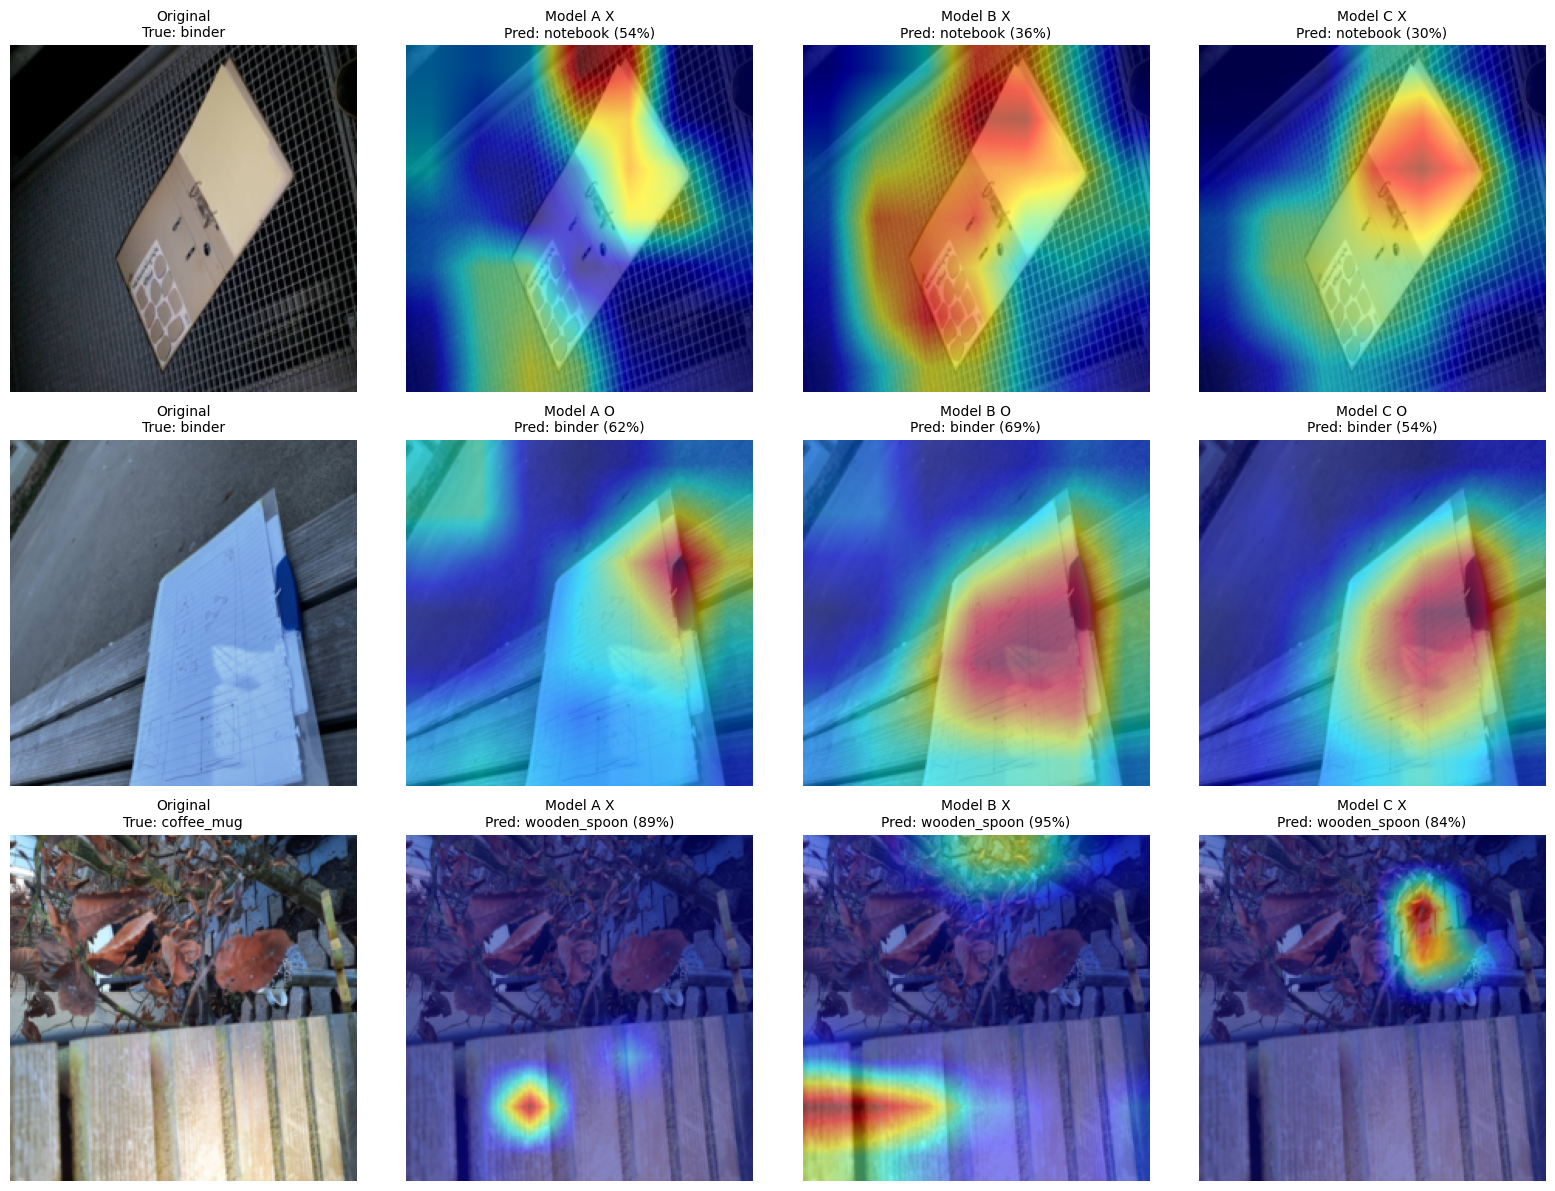

Grid saved to: ./gradcam_outputs/gradcam_comparison_grid.png

GRAD-CAM VISUALIZATION COMPLETE!
Individual images: C:\Users\Elahe\Desktop\Repo-xAI-Proj-B\block-4-5-model-ab-fatemeh\notebooks\gradcam_outputs
Comparison grid: C:\Users\Elahe\Desktop\Repo-xAI-Proj-B\block-4-5-model-ab-fatemeh\notebooks\gradcam_outputs/gradcam_comparison_grid.png


In [16]:
# ╔═══════════════════════════════════════════════════════════════════════════════╗
# ║  BLOCK 10 - GRAD-CAM EXPLAINABILITY                                            ║
# ╚═══════════════════════════════════════════════════════════════════════════════╝
#
# What this block does:
# ─────────────────────
# Uses Grad-CAM to visualize which parts of the image each model focuses on.
# Helps understand model decision-making and compare different strategies.
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from torchvision import datasets, transforms
import torch

# ============ HELPER FUNCTIONS ============
def unnormalize_image(img_tensor):
    """Unnormalize image back to original"""
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img_tensor.cpu().numpy()
    img = (img * std[:, None, None]) + mean[:, None, None]
    img = np.clip(img, 0, 1)
    img = np.transpose(img, (1, 2, 0))
    return img

def save_gradcam_overlay(img_tensor, cam_mask, out_path, title=""):
    """Save Grad-CAM overlay image"""
    img = unnormalize_image(img_tensor)
    cam_overlay = show_cam_on_image(img, cam_mask, use_rgb=True)
    plt.figure(figsize=(5, 5))
    plt.imshow(cam_overlay)
    plt.axis('off')
    plt.title(title, fontsize=9)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close()

def display_gradcam_grid(test_dataset, models_dict, indices, device, class_names):
    """Display Grad-CAM comparison grid"""
    n_images = len(indices)
    n_models = len(models_dict)

    if n_models == 0 or n_images == 0:
        print("No models or images to display.")
        return

    fig, axes = plt.subplots(n_images, n_models + 1, figsize=(4*(n_models+1), 4*n_images))
    if n_images == 1:
        axes = [axes]

    for row, idx in enumerate(indices):
        if idx >= len(test_dataset):
            continue

        x, y = test_dataset[idx]
        img = unnormalize_image(x)
        true_name = class_names[y]

        axes[row][0].imshow(img)
        axes[row][0].set_title(f"Original\nTrue: {true_name}", fontsize=10)
        axes[row][0].axis('off')

        for col, (model_key, model) in enumerate(models_dict.items(), start=1):
            model.eval()
            model = model.to(device)
            target_layer = model.layer4[-1]

            for param in model.parameters():
                param.requires_grad = True

            x_b = x.unsqueeze(0).to(device)

            with GradCAM(model=model, target_layers=[target_layer]) as cam:
                targets = [ClassifierOutputTarget(y)]
                cam_map = cam(input_tensor=x_b, targets=targets)

            with torch.no_grad():
                logits = model(x_b)
                probs = torch.softmax(logits, dim=1)[0]
                pred = int(probs.argmax().item())
                conf = float(probs.max().item())

            pred_name = class_names[pred]
            correct = "O" if pred == y else "X"

            cam_overlay = show_cam_on_image(img, cam_map[0], use_rgb=True)

            axes[row][col].imshow(cam_overlay)
            axes[row][col].set_title(f"Model {model_key} {correct}\nPred: {pred_name} ({conf*100:.0f}%)", fontsize=10)
            axes[row][col].axis('off')

    plt.tight_layout()
    plt.savefig("./gradcam_outputs/gradcam_comparison_grid.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Grid saved to: ./gradcam_outputs/gradcam_comparison_grid.png")

# ============ Setup ============
print("="*60)
print("BLOCK 10: GRAD-CAM EXPLAINABILITY")
print("="*60)

# Robust path detection for test directory
possible_test_paths = [
    Path(r"C:/Users/Elahe/Desktop/Repo-xAI-Proj-B/block-4-5-model-ab-fatemeh/notebooks/data/xAI_ImageNet1k_OwnTestSet/xai-imagenet10-hard-test"),
    Path("./data/xAI_ImageNet1k_OwnTestSet/xai-imagenet10-hard-test"),
    Path("../notebooks/data/xAI_ImageNet1k_OwnTestSet/xai-imagenet10-hard-test"),
]

test_dir = None
for p in possible_test_paths:
    if p.exists() and p.is_dir():
        test_dir = p
        print(f"Found test directory: {p.resolve()}")
        break

if test_dir is None:
    print("Test directory not found. Checked paths:")
    for p in possible_test_paths:
        print(f"  - {p.resolve()}")

input_size = 224
test_transform = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

if test_dir.exists():
    test_dataset = datasets.ImageFolder(test_dir, test_transform)
    test_class_names = test_dataset.classes
    print(f"Test dataset loaded: {len(test_dataset)} images")
else:
    test_dataset = None
    test_class_names = []

# ============ COLLECT MODELS ============
models_to_explain = {}
if 'model_A' in globals() and model_A is not None:
    models_to_explain['A'] = model_A
if 'model_B' in globals() and model_B is not None:
    models_to_explain['B'] = model_B
if 'model_C' in globals() and model_C is not None:
    models_to_explain['C'] = model_C
if 'model_D' in globals() and model_D is not None:
    models_to_explain['D'] = model_D

print(f"\nModels available for Grad-CAM: {list(models_to_explain.keys())}")

# ============ GENERATE GRAD-CAM ============
if test_dataset is not None and len(models_to_explain) > 0:

    OUT_DIR = Path("./gradcam_outputs")
    OUT_DIR.mkdir(exist_ok=True)

    indices_to_viz = [0, 100, 500, 1000, 2000]
    indices_to_viz = [i for i in indices_to_viz if i < len(test_dataset)]

    print(f"\nGenerating Grad-CAM for {len(indices_to_viz)} test images...")
    print(f"Output directory: {OUT_DIR.resolve()}\n")

    print("Part 1: Saving individual Grad-CAM images...")

    for key, model in models_to_explain.items():
        print(f"  Processing Model {key}...")
        model.eval()
        model = model.to(device)
        target_layer = model.layer4[-1]

        for param in model.parameters():
            param.requires_grad = True

        with GradCAM(model=model, target_layers=[target_layer]) as cam_engine:
            for idx in indices_to_viz:
                x, y = test_dataset[idx]
                x_b = x.unsqueeze(0).to(device)

                targets = [ClassifierOutputTarget(y)]
                cam_map = cam_engine(input_tensor=x_b, targets=targets)

                with torch.no_grad():
                    logits = model(x_b)
                    probs = torch.softmax(logits, dim=1)[0]
                    pred = int(probs.argmax().item())
                    conf = float(probs.max().item())

                true_name = test_class_names[y]
                pred_name = test_class_names[pred]
                correct = "O" if pred == y else "X"

                title = f"Model {key} | {correct} | True: {true_name} | Pred: {pred_name} ({conf*100:.1f}%)"
                filename = f"gradcam_M{key}_idx{idx}_{true_name}_pred_{pred_name}.png"
                out_path = OUT_DIR / filename

                save_gradcam_overlay(x, cam_map[0], out_path, title=title)

    print(f"  Saved {len(indices_to_viz) * len(models_to_explain)} individual images.\n")

    print("Part 2: Generating comparison grid...")
    grid_indices = indices_to_viz[:3]

    display_gradcam_grid(
        test_dataset=test_dataset,
        models_dict=models_to_explain,
        indices=grid_indices,
        device=device,
        class_names=test_class_names
    )

    print("\nGRAD-CAM VISUALIZATION COMPLETE!")
    print(f"Individual images: {OUT_DIR.resolve()}")
    print(f"Comparison grid: {OUT_DIR.resolve()}/gradcam_comparison_grid.png")

else:
    print("\nCANNOT RUN GRAD-CAM")
    if test_dataset is None:
        print("Test dataset not found.")
    if len(models_to_explain) == 0:
        print("No trained models found. Run Block 8 or Block 8.5 first.")

---

## Quick Reference - Execution Order

| Block | Name | Run When |
|-------|------|----------|
| 0 | Imports & Setup | **EVERY TIME** (after kernel restart) |
| 1 | Dataset Loading | **EVERY TIME** (after kernel restart) |
| 2 | Training Function | **EVERY TIME** (after kernel restart) |
| 2.5 | Test Evaluation Function | **EVERY TIME** (after kernel restart) |
| 3 | Flower Documentation | READ ONLY |
| 4 | Model A Definition | **EVERY TIME** (after kernel restart) |
| 5 | Model B Definition | **EVERY TIME** (after kernel restart) |
| 6 | Model C Definition | **EVERY TIME** (after kernel restart) |
| 7 | Model D Definition | **EVERY TIME** (after kernel restart) |
| 8 | Train All Models | **ONCE** (takes 30-60 min) - First time only |
| **8.5** | **Load Saved Models** | **USE THIS** after first training (fast!) |
| 9 | Test Evaluation | **AFTER TRAINING or LOADING** |
| 10 | Grad-CAM Explainability | **AFTER TRAINING or LOADING** |

---

## Two Workflows:

### First Time (Training):
```
Restart kernel → Run 0-7 → Run Block 8 (train) → Run 9, 10
```

### After First Time (Load Saved Models):
```
Restart kernel → Run 0-7 → Run Block 8.5 (load) → Run 9, 10
```

**Block 8.5 loads models in seconds instead of 30-60 minutes!**